<img src="https://heig-vd.ch/docs/default-source/doc-global-newsletter/2020-slim.svg" alt="Logo HEIG-VD" style="width: 80px;" align="right"/>

# Cours PCD - Labo 1

# Extraction d'attributs pour la détection du spam

## Résumé

Le but de ce travail est de réaliser des expériences de classification d'emails en *spam* ou *ham* (c'est-à-dire non-spam) grâce aux données et au code fourni intégralement dans ce notebook Jupyter.

Votre objectif sera de chercher les meilleurs attributs (*features*) qu'on puisse extraire des emails, ainsi que les classifieurs, afin de maximiser le score F1 de la classification spam/non-spam.  Les classifieurs utilisés seront de la famille Naive Bayes de Scikit-learn.

Veuillez rendre un notebook avec votre meilleure stratégie.  Présentez clairement les options et leurs résultats, et commentez-les brièvement.

*Source* : l'idée du labo vient du [premier notebook de Gan Sie Huai](https://github.com/huai99/Email-Spam-Detection-Python) avec plusieurs changements et mises à jour.

## 1. Obtention des données

Veuillez télécharger l'archive d'emails depuis Cyberlearn.  Ou téléchargez les cinq archives commençant par `20030228_` depuis https://spamassassin.apache.org/old/publiccorpus/.  Décompressez-les dans un dossier de votre choix dont vous indiquerez le chemin relatif dans `path`.

In [4]:
import os
import glob
import numpy as np
import email


In [5]:
path = 'spam_data/'

In [6]:
easy_ham_paths = glob.glob(path+'easy_ham/*')
easy_ham_2_paths = glob.glob(path+'easy_ham_2/*')
hard_ham_paths = glob.glob(path+'hard_ham/*')
spam_paths = glob.glob(path+'spam/*')
spam_2_paths = glob.glob(path+'spam_2/*')

In [7]:
def get_email_content(email_path):
    file = open(email_path,encoding='latin1')
    try:
        msg = email.message_from_file(file)
        for part in msg.walk():
            if part.get_content_type() == 'text/plain':
                return part.get_payload() # prints the raw text
    except Exception as e:
        print(e)
        
        
def get_email_content_bulk(email_paths):
    email_contents = []
    counter = 0
    for o in email_paths:
        content = get_email_content(o)
        email_contents.append(content)
        counter+= 1
    return email_contents




## 2. Division en *train* et *test*
Le code suivant vous permet de diviser les données en *train* et *test* (sous-ensembles d'entraînement et de test).  Veuillez l'exécuter pour créer ces deux ensembles.

In [9]:
from sklearn.model_selection import train_test_split

In [10]:
ham_path = [easy_ham_paths, easy_ham_2_paths, hard_ham_paths]
spam_path = [spam_paths, spam_2_paths]

### Setup ham

In [12]:
ham_sample = np.array([train_test_split(o,random_state=42) for o in ham_path], dtype=object)

In [13]:
for o in ham_sample:
    print(len(o[0]), len(o[1]))

# First element is train set, second is test set

1875 626
1050 351
188 63


In [14]:
ham_train = np.array([])
ham_test = np.array([])
for o in ham_sample:
    ham_train = np.concatenate((ham_train, o[0]), axis=0)
    ham_test  = np.concatenate((ham_test,  o[1]), axis=0)

In [15]:
ham_train.shape, ham_test.shape

((3113,), (1040,))

### Setup Spam

In [17]:
spam_sample = np.array([train_test_split(o, random_state=42) for o in spam_path], dtype=object)

In [18]:
for o in spam_sample:
    print(len(o[0]), len(o[1]))

375 126
1047 350


In [19]:
spam_train = np.array([])
spam_test = np.array([])
for o in spam_sample:
    spam_train = np.concatenate((spam_train,o[0]),axis=0)
    spam_test = np.concatenate((spam_test,o[1]),axis=0)

In [20]:
spam_train.shape, spam_test.shape

((1422,), (476,))

### Create labels / Mix Ham & Spam mails

In [22]:
ham_train_label = [0]*ham_train.shape[0] # set labels as 0's when it's a ham
spam_train_label = [1]*spam_train.shape[0] # set labels as 1's when it's a spam
x_train = np.concatenate((ham_train,spam_train))
y_train = np.concatenate((ham_train_label,spam_train_label))

In [23]:
ham_test_label = [0]*ham_test.shape[0]
spam_test_label = [1]*spam_test.shape[0]
x_test = np.concatenate((ham_test,spam_test))
y_test = np.concatenate((ham_test_label,spam_test_label))

In [24]:
train_shuffle_index = np.random.permutation(np.arange(0,x_train.shape[0]))
test_shuffle_index = np.random.permutation(np.arange(0,x_test.shape[0]))

In [25]:
x_train = x_train[train_shuffle_index]
y_train = y_train[train_shuffle_index]

In [26]:
x_test = x_test[test_shuffle_index]
y_test = y_test[test_shuffle_index]

In [27]:
x_train = get_email_content_bulk(x_train)
x_test = get_email_content_bulk(x_test)

In [28]:
def remove_null(datas,labels):
    not_null_idx = [i for i,o in enumerate(datas) if o is not None]
    return np.array(datas)[not_null_idx],np.array(labels)[not_null_idx]

In [29]:
x_train,y_train = remove_null(x_train,y_train)
x_test,y_test = remove_null(x_test,y_test)

**Question :** combien d'emails y a-t-il dans le jeu d'entraînement et dans le jeu de test ?  Combien de spam et de ham, respectivement ?  Veuillez écrire le code qui fournit les réponses ci-dessous.

### Combien d'emails y a-t-il dans le jeu d'entraînement et dans le jeu de test (Après le remove des nulls)?

In [32]:
x_test.shape[0]

1255

Il y a **1255** emails ( Les nombres ne sont pas fi

### Combien de spam et de ham dans le jeu de test (Après remove des nulls)?

In [35]:
print(np.sum(y_test == 1)) # Spam
print(np.sum(y_test == 0)) # Ham

250
1005


On a **250** Spam et **1005** Ham

## 3. Pré-traitement et nettoyage des données

### 3.1 Traitements de bas niveau

In [38]:
import re
import string
from nltk.tokenize import word_tokenize

In [39]:
def remove_hyperlink(word):
    return  re.sub(r"http\S+", "", word)

In [40]:
def to_lower(word):
    result = word.lower()
    return result

In [41]:
def remove_number(word):
    result = re.sub(r'\d+', '', word)
    return result

In [42]:
def remove_punctuation(word):
    result = word.translate(str.maketrans(dict.fromkeys(string.punctuation)))
    return result

In [43]:
def remove_whitespace(word):
    result = word.strip()
    return result

In [44]:
def replace_newline(word):
    return word.replace('\n',' ')

**Votre mission :** dans la fonction suivante, insérer dans le tableau `cleaning_utils` les noms des fonctions de pré-traitement que vous souhaitez utiliser afin d'obtenir le meilleur filtre anti-spam.   Veuillez commenter brièvement les raisons de votre choix.

### Choix
- On ne supprime pas les hyperlinks, car souvent les emails spams en contiennent plus que les emails ham.
- On convertit les majuscules en minuscules pour que "FREE", "Free" et "free" soient reconnus comme un seul et même mot, évitant ainsi de fausser les statistiques
- En théorie les nombres peuvent être utiles pour détecter le spam. Mais en utilisant la représentation TF-IDF, les nombres sont surtout du bruit, il est donc préférable de les enlever.
- La ponctuation pourrait contenir plus de "!" lorsqu'il s'agit de mail SPAM, mais je pense qu'on peut quand même enlever la ponctuation car c'est minime comparé au gain de simplification.
- Les espaces sont important pour différencier les mots, mais ici strip enlève seulement les espaces en trop au début et a la fin du string, ce qui enlève aucun risque.
- On peut remplacer le retour a la ligne par un espace, ça évite de casser des phrase et c'est propre.

In [148]:
def clean_up_pipeline(sentence):
    cleaning_utils = [to_lower, remove_punctuation, remove_whitespace, replace_newline, remove_number]
    for o in cleaning_utils:
        sentence = o(sentence)
    return sentence

In [48]:
x_train = [clean_up_pipeline(o) for o in x_train]
x_test = [clean_up_pipeline(o) for o in x_test]

### 3.2. Traitements linguistiques avec NLTK

Veuillez installer la librairie NLTK avec Conda ou `pip`, voir instructions à https://www.nltk.org.

In [50]:
from nltk.tokenize import word_tokenize
from sklearn.feature_extraction._stop_words import ENGLISH_STOP_WORDS
from nltk.stem import PorterStemmer
from nltk.stem import WordNetLemmatizer

In [51]:
stemmer = PorterStemmer()
lemmatizer = WordNetLemmatizer()

In [52]:
def remove_stop_words(words):
    result = [i for i in words if i not in ENGLISH_STOP_WORDS]
    return result

In [53]:
def word_stemmer(words):
    return [stemmer.stem(o) for o in words]

In [54]:
def word_lemmatizer(words):
    return [lemmatizer.lemmatize(o) for o in words]

**Votre mission :** dans la fonction suivante, insérer dans le tableau `cleaning_utils` les noms des fonctions de traitement linguistique que vous souhaitez utiliser afin d'obtenir le meilleur filtre anti-spam.  Veuillez commenter brièvement les raisons de votre choix.

- On applique forcément le "remove_stop_words" parce que les mots comme "of","a", "an" vont pas nous aider a distinguer un ham d'un spam
- Je pense que le stemmer et le lemmatizer sont bien les 2 (a ne pas utiliser ensemble). Mais je préfère le lemmatizer parce que le lemmatizer peut etre un peu aggresif en réduisant les mots

In [57]:
def clean_token_pipeline(words):
    cleaning_utils = [remove_stop_words, word_lemmatizer]
    for o in cleaning_utils:
        words = o(words)
    return words

**Remarque:** la tokenization peut prendre plusieurs minutes, vu la quantité de données.

In [59]:
import nltk
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('wordnet')


x_train = [word_tokenize(o) for o in x_train]
x_test = [word_tokenize(o) for o in x_test]

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\Akame\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\Akame\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\Akame\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


In [60]:
x_train = [clean_token_pipeline(o) for o in x_train]
x_test = [clean_token_pipeline(o) for o in x_test]

In [61]:
x_train = [" ".join(o) for o in x_train]
x_test = [" ".join(o) for o in x_test]

# 4. Extraction des attributs (*feature extraction*)

À cette étape, on transforme les textes des emails en une série d'attributs.  Les méthodes proposées par Scikit-learn permettent de décider quels mots on garde comme attributs, puis les valeurs de chaque attribut pour chaque email.  Résultat : au lieu d'une chaîne de caractères, chaque email est représenté par une suite de nombres (de la même taille pour tous).

**Votre mission** : faire des expériences pour choisir entre les deux méthodes suivantes celle qui aboutira aux meilleurs résultats.

In [63]:
from sklearn.feature_extraction.text import CountVectorizer

In [64]:
vectorizer = CountVectorizer()

In [65]:
#from sklearn.feature_extraction.text import TfidfVectorizer

In [66]:
#vectorizer = TfidfVectorizer()

Transformation des textes des emails en vecteurs d'attributs.

In [68]:
def convert_to_feature(vectorizer, raw_tokenize_data):
    return vectorizer.transform(raw_tokenize_data)

In [69]:
vectorizer.fit(x_train)

,"input input: {'filename', 'file', 'content'}, default='content'- If `'filename'`, the sequence passed as an argument to fit is expected to be a list of filenames that need reading to fetch the raw content to analyze.- If `'file'`, the sequence items must have a 'read' method (file-like object) that is called to fetch the bytes in memory.- If `'content'`, the input is expected to be a sequence of items that can be of type string or byte.",'content'
,"encoding encoding: str, default='utf-8'If bytes or files are given to analyze, this encoding is used todecode.",'utf-8'
,"decode_error decode_error: {'strict', 'ignore', 'replace'}, default='strict'Instruction on what to do if a byte sequence is given to analyze thatcontains characters not of the given `encoding`. By default, it is'strict', meaning that a UnicodeDecodeError will be raised. Othervalues are 'ignore' and 'replace'.",'strict'
,"strip_accents strip_accents: {'ascii', 'unicode'} or callable, default=NoneRemove accents and perform other character normalizationduring the preprocessing step.'ascii' is a fast method that only works on characters that havea direct ASCII mapping.'unicode' is a slightly slower method that works on any characters.None (default) means no character normalization is performed.Both 'ascii' and 'unicode' use NFKD normalization from:func:`unicodedata.normalize`.",None
,"lowercase lowercase: bool, default=TrueConvert all characters to lowercase before tokenizing.",True
,"preprocessor preprocessor: callable, default=NoneOverride the preprocessing (strip_accents and lowercase) stage whilepreserving the tokenizing and n-grams generation steps.Only applies if ``analyzer`` is not callable.",None
,"tokenizer tokenizer: callable, default=NoneOverride the string tokenization step while preserving thepreprocessing and n-grams generation steps.Only applies if ``analyzer == 'word'``.",None
,"stop_words stop_words: {'english'}, list, default=NoneIf 'english', a built-in stop word list for English is used.There are several known issues with 'english' and you shouldconsider an alternative (see :ref:`stop_words`).If a list, that list is assumed to contain stop words, all of whichwill be removed from the resulting tokens.Only applies if ``analyzer == 'word'``.If None, no stop words will be used. In this case, setting `max_df`to a higher value, such as in the range (0.7, 1.0), can automatically detectand filter stop words based on intra corpus document frequency of terms.",None
,"token_pattern token_pattern: str or None, default=r""(?u)\\b\\w\\w+\\b""Regular expression denoting what constitutes a ""token"", only usedif ``analyzer == 'word'``. The default regexp select tokens of 2or more alphanumeric characters (punctuation is completely ignoredand always treated as a token separator).If there is a capturing group in token_pattern then thecaptured group content, not the entire match, becomes the token.At most one capturing group is permitted.",'(?u)\\b\\w\\w+\\b'
,"ngram_range ngram_range: tuple (min_n, max_n), default=(1, 1)The lower and upper boundary of the range of n-values for differentword n-grams or char n-grams to be extracted. All values of n suchsuch that min_n <= n <= max_n will be used. For example an``ngram_range`` of ``(1, 1)`` means only unigrams, ``(1, 2)`` meansunigrams and bigrams, and ``(2, 2)`` means only bigrams.Only applies if ``analyzer`` is not callable.","(1, ...)"
,"analyzer analyzer: {'word', 'char', 'char_wb'} or callable, default='word'Whether the feature should be made of word n-gram or charactern-grams.Option 'char_wb' creates character n-grams only from text insideword boundaries; n-grams at the edges of words are padded with space.If a callable is passed it is used to extract the sequence of featuresout of the raw, unprocessed input... versionchanged:: 0.21Since v0.21, if ``input`` is ``filename`` or ``file``, the data isfirst read from the file and then passed to the given callableanalyzer.",'word'


In [70]:
x_train_features = convert_to_feature(vectorizer, x_train)
x_test_features  = convert_to_feature(vectorizer, x_test)

## 5. Choix de la méthode de classification et entraînement

Dans cette section, vous allez pouvoir choisir le classifieur.  On vous propose de travailler avec un modèle de type *Naïve Bayes*, à choisir parmi plusieurs variantes disponibles dans Scikit-learn, et qui sont décrites à https://scikit-learn.org/stable/modules/naive_bayes.html.

Voici à titre d'exemple l'utilisation du classifieur *Naïve Bayes Multinomial*.

In [72]:
import sklearn.naive_bayes as nb

In [73]:
clf = nb.ComplementNB()

In [74]:
clf.fit(x_train_features.toarray(), y_train) # entraînement du modèle

,"alpha alpha: float or array-like of shape (n_features,), default=1.0Additive (Laplace/Lidstone) smoothing parameter(set alpha=0 and force_alpha=True, for no smoothing).",1.0
,"force_alpha force_alpha: bool, default=TrueIf False and alpha is less than 1e-10, it will set alpha to1e-10. If True, alpha will remain unchanged. This may causenumerical errors if alpha is too close to 0... versionadded:: 1.2.. versionchanged:: 1.4 The default value of `force_alpha` changed to `True`.",True
,"fit_prior fit_prior: bool, default=TrueOnly used in edge case with a single class in the training set.",True
,"class_prior class_prior: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. Not used.",None
,"norm norm: bool, default=FalseWhether or not a second normalization of the weights is performed. Thedefault behavior mirrors the implementations found in Mahout and Weka,which do not follow the full algorithm described in Table 9 of thepaper.",False


In [75]:
clf.score(x_train_features.toarray(),y_train) # score F1 du modèle sur les données d'entraînement

0.9921486521852918

**Votre mission :** essayer plusieurs classifieurs basés sur l'approche *Naïve Bayes* et choisir celui qui aboutit au meilleur score *sur les données de test*, qui sera calculé dans la section suivante.

## 6. Évaluation du classifieur entraîné

Dans cette section, vous allez demander au classifieur de classer les données de test (non vues à l'entraînement), et calculer (grâce aux réponses correctes) plusieurs scores qui mesurent les performances de détection de spam.  Veuillez répondre aux questions posées en fin de section.

In [78]:
from sklearn.metrics import confusion_matrix, f1_score, precision_score, recall_score

In [79]:
y_predict = clf.predict(x_test_features.toarray()) # réponses du système sur les données de test

In [80]:
print("Precision: {:.2f}%".format(100 * precision_score(y_test, y_predict)))
print("Recall:    {:.2f}%".format(100 * recall_score(y_test, y_predict)))
print("F1-score:  {:.2f}%".format(100 * f1_score(y_test, y_predict)))

Precision: 97.82%
Recall:    89.60%
F1-score:  93.53%


In [81]:
confusion_matrix(y_test, y_predict) # affichage élémentaire de la matrice de confusion

array([[1000,    5],
       [  26,  224]])

In [82]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

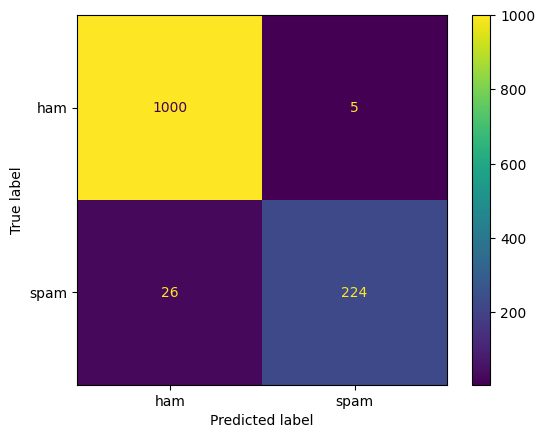

In [83]:
# affichage graphique de la matrice de confusion
ConfusionMatrixDisplay.from_predictions(y_test, y_predict, display_labels = ['ham', 'spam']) 
plt.show()

**Veuillez répondre ici** aux questions suivantes :

1. Quel était votre premier score F1 obtenu ?  Quel est votre meilleur score ?  De combien avez-vous progressé grâce à vos choix judicieux ?

2. Quels choix de pré-traitement (section 3) vous ont conduit-e à la meilleure solution ?

3. Quelle représentation des emails vous a conduit-e à la meilleure solution ?

4. Quel classifieur vous a conduit-e à la meilleure solution ?

# Réponses

## 1 Scores F1 et progression

- **Premier F1 score obtenu** : 55.04 %  
- **Meilleur F1 score obtenu** : 96.32 %  
- **Progression** : +41.28 %.  
- **Modification principale** : utilisation de `CountVectorizer()` au lieu de `TfidfVectorizer()`.

---

## 2 Choix de pré-traitement

Les étapes de pré-traitement ayant conduit à la meilleure solution :

- **Hyperlinks** : conservés,
- **Majuscules** : converties en minuscules 
- **Nombres** : supprimés.
- **Ponctuation** : supprimée
- **Espaces** : `strip()`
- **Retours à la ligne** : remplacés par un espace
- **Stop words** : supprimés 
- **Lemmatization** : préférée au stemmer → moins agressive et réduit les mots à leur forme de base sans créer de racines artificielles.

> Observation : le stemmer a donné des scores légèrement plus élevés sur certains essais, mais avec un **écart-type plus important**, donc moins stable que le lemmatizer.

---

## 3 Représentation des emails

- La **représentation TF-IDF** a été remplacée par **`CountVectorizer()`**, ce qui a conduit à une amélioration significative du F1-score.  
- C’est la modification la plus impactante du F1-Score.

---

## 4 Comparaison des simulations et choix du classifieur

### Table 1 : CountVectorizer + ComplementNB

| Pré-traitement | Score 1 | Score 2 | Score 3 | Score 4 | Score 5 | Moyenne |
|----------------|---------|---------|---------|---------|---------|---------|
| Lemmatizer      | 94.65   | 94.00   | 93.70   | 94.21   | 94.16   | 94.14   |
| Stemmer         | 94.72   | 96.32   | 93.61   | 92.89   | 95.07   | 94.52   |

> Observation : Le stemmer donne le score maximal (96.32 %) mais avec plus de variabilité, donc moins stable.


### Table 2 : CountVectorizer + MultinomialNB

| Pré-traitement | Score 1 | Score 2 | Score 3 | Score 4 | Score 5 | Moyenne |
|----------------|---------|---------|---------|---------|---------|---------|
| Lemmatizer      | 94.99   | 94.32   | 92.43   | 93.91   | 93.28   | 93.99   |
| Stemmer         | 93.60      | 94.14    | 94.98 | 92.12    | 95.29 | 94.02     |



> Meilleur compromis stabilité/performance : **ComplementNB + Lemmatizer**  
> Top score atteint : **96.32 %** avec **ComplementNB + Stemmer**, mais avec plus de variance.


Donc le meilleur modèle globalement est **CopmlementNB**

---

## 5 Conclusion

Relancer plusieurs fois le notebook a été essentiel pour comparer les modèles objectivement et éviter de se fier à un score isolé potentiellement trompeur. C'est cette démarche répétée qui a permis d'identifier **ComplementNB + Lemmatizer** comme la solution la plus stable et performante